# 02 - Exploratory data analysis
Plots and checks on the training and validation data.
The test sets stays unseen.

Before running: run 01_data_preparation once, so data_cache/ exists.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

CLASS_NAMES = ["good", "broken", "heavyload"]

# load the data saved by 01_data_preparation
X_train = np.load("data_cache/X_train.npy")
y_train = np.load("data_cache/y_train.npy")
X_val = np.load("data_cache/X_val.npy")
y_val = np.load("data_cache/y_val.npy")
val_recordings = np.load("data_cache/val_recordings.npy")

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (357, 132300) Val: (442, 132300)


In [2]:
# Log-mel spectrogram: used here for plots
# using librosa to comute the log-mel spectrograms.
def log_mel(x):
    mel = librosa.feature.melspectrogram(y=x, sr=44100, n_fft=2048, hop_length=512, n_mels=64)
    return librosa.power_to_db(mel)                     # makes one clip into 64x259 matrix

## 1. Waveforms and spectrograms per class

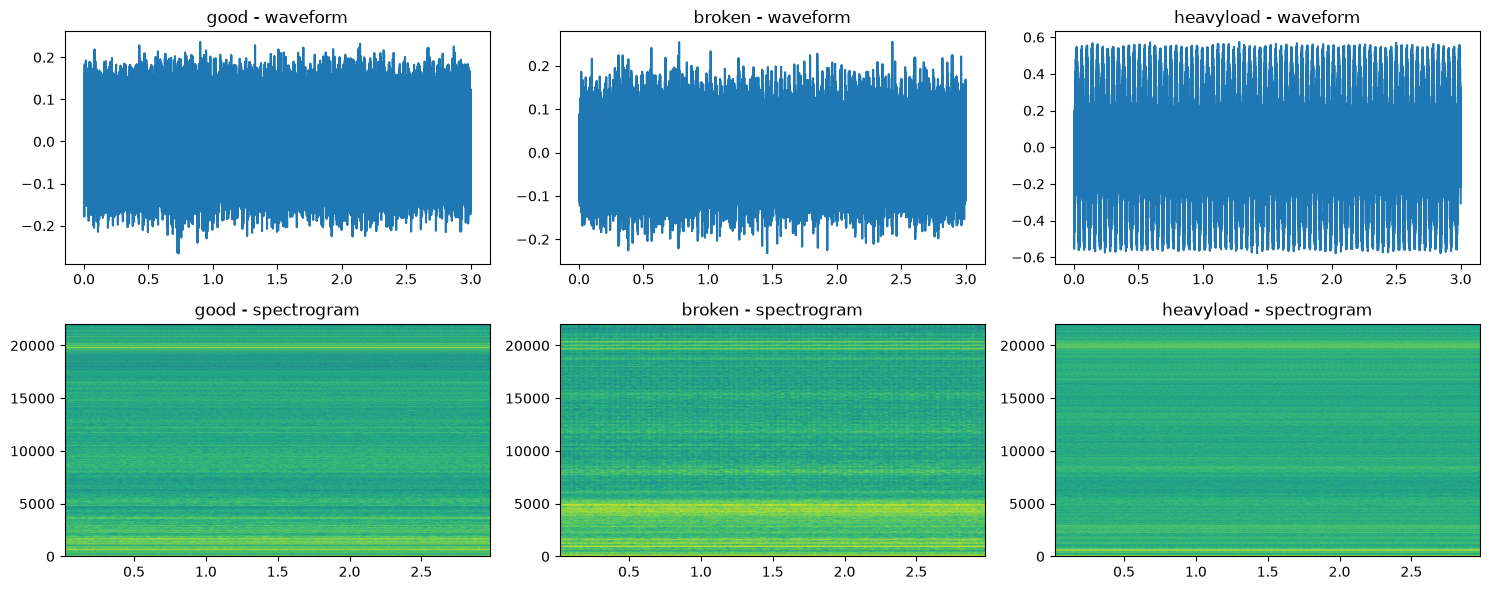

In [3]:
# Training plot waveforms and spectrograms per class per clip.
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for label in range(3):
    x = X_train[y_train == label][67]      # change clip to plot


    time = np.arange(len(x)) / 44100
    axes[0, label].plot(time, x)
    axes[0, label].set_title(CLASS_NAMES[label] + " - waveform")

    axes[1, label].specgram(x, Fs=44100, NFFT=2048, noverlap=1536)
    axes[1, label].set_title(CLASS_NAMES[label] + " - spectrogram")

plt.tight_layout()
plt.show()

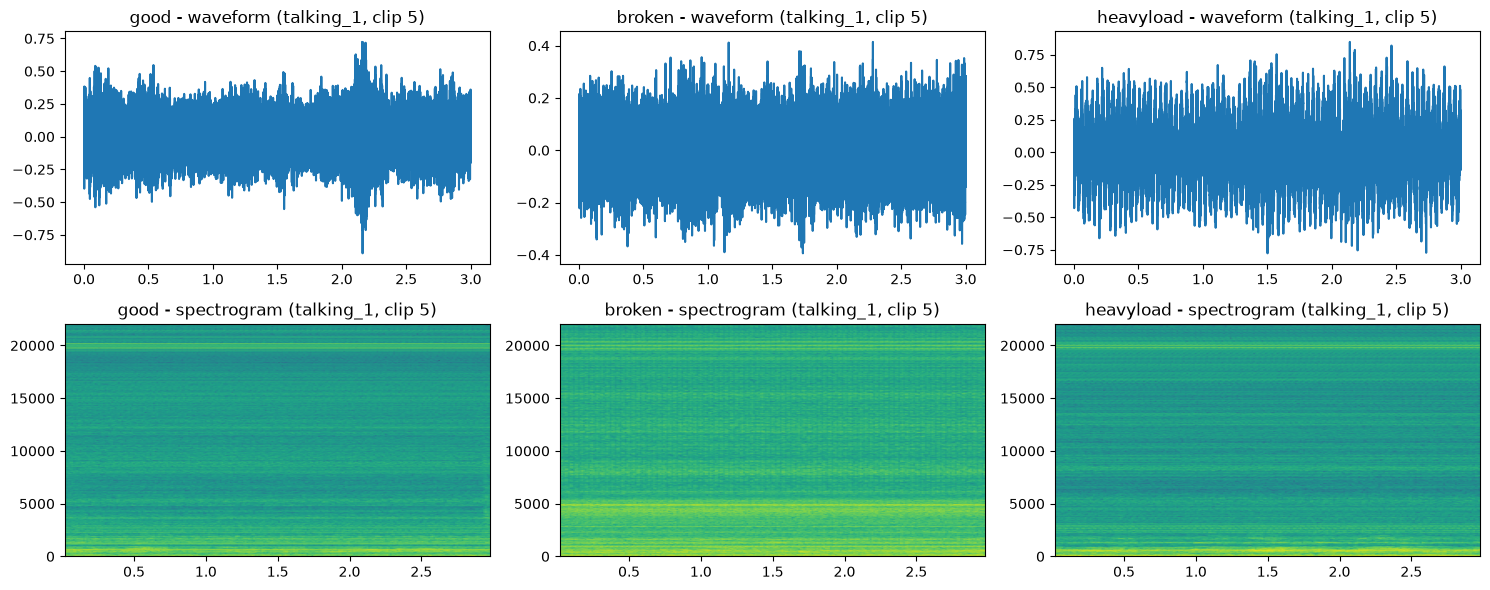

In [4]:
# validation plot waveforms and spectrograms per class per clip.
RECORDING = "talking_1"     # "atmo_medium" or "talking_1"
CLIP = 5                      # Change clip

val_recordings = np.array(val_recordings)
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

for label in range(3):
    clips = X_val[(y_val == label) & (val_recordings == RECORDING)]
    x = clips[CLIP] 

    time = np.arange(len(x)) / 44100
    axes[0, label].plot(time, x)
    axes[0, label].set_title(CLASS_NAMES[label] + " - waveform (" + RECORDING + ", clip " + str(CLIP) + ")")

    axes[1, label].specgram(x, Fs=44100, NFFT=2048, noverlap=1536)
    axes[1, label].set_title(CLASS_NAMES[label] + " - spectrogram (" + RECORDING + ", clip " + str(CLIP) + ")")

plt.tight_layout()
plt.show()

### Log-mel spectrograms (what the CNN sees)

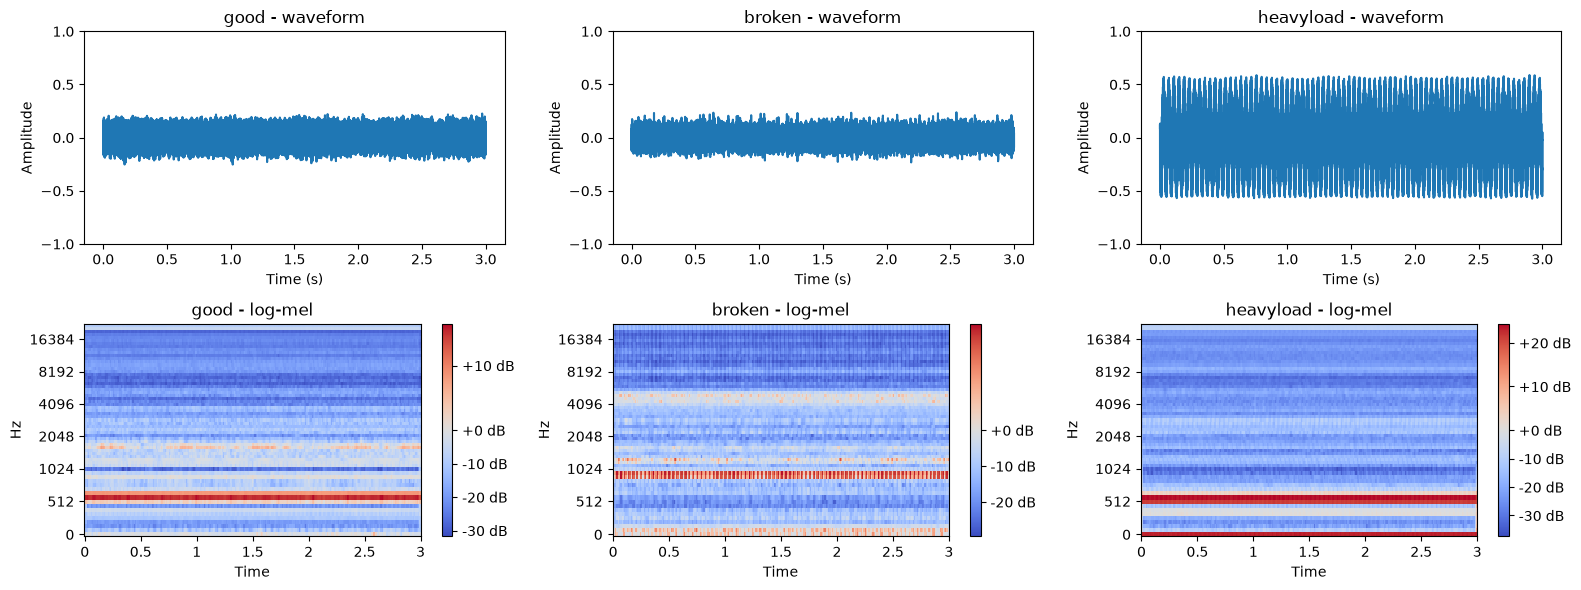

In [5]:
# Training: waveform + log-mel spectrogram per class
CLIP = 5   # what clip to plot

fig, axes = plt.subplots(2, 3, figsize=(16, 6))     # 2 rows: waveform on top, log-mel below

for label in range(3):
    x = X_train[y_train == label][CLIP]
    time = np.arange(len(x)) / 44100

    # top row: waveform
    axes[0, label].plot(time, x)
    axes[0, label].set_ylim(-1, 1)                    # same scale for all classes
    axes[0, label].set_title(CLASS_NAMES[label] + " - waveform")
    axes[0, label].set_xlabel("Time (s)")
    axes[0, label].set_ylabel("Amplitude")

    # bottom row: log-mel spectrogram (what the CNN sees)
    img = librosa.display.specshow(log_mel(x), sr=44100, hop_length=512,
                                   x_axis="time", y_axis="mel", ax=axes[1, label])
    axes[1, label].set_title(CLASS_NAMES[label] + " - log-mel")
    fig.colorbar(img, ax=axes[1, label], format="%+2.0f dB")

plt.tight_layout()
plt.show()

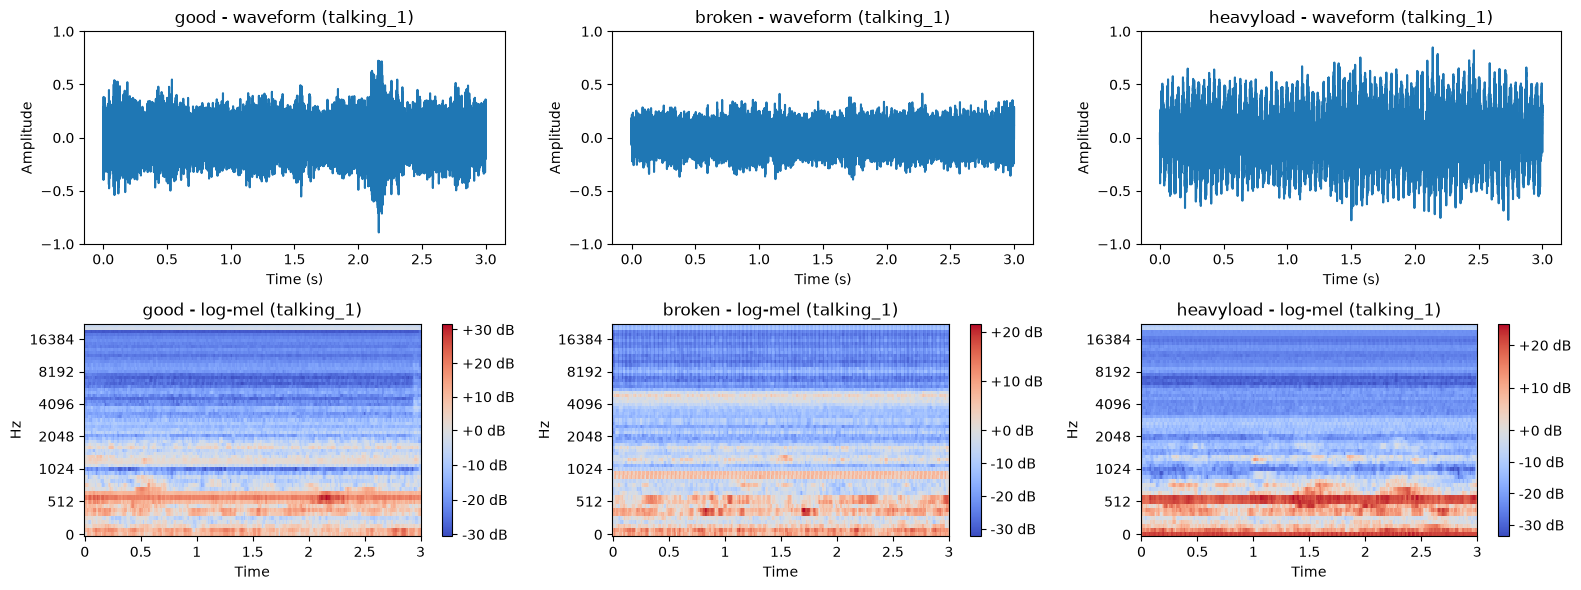

In [6]:
# Validation: waveform + log-mel spectrogram per class
CLIP = 5                  # which clip to plot
RECORDING = "talking_1"   # "talking_1" or "atmo_medium"

val_recordings = np.array(val_recordings)   # needed so == compares every element

fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for label in range(3):
    x = X_val[(y_val == label) & (val_recordings == RECORDING)][CLIP]
    time = np.arange(len(x)) / 44100

    # top row: waveform
    axes[0, label].plot(time, x)
    axes[0, label].set_ylim(-1, 1)
    axes[0, label].set_title(CLASS_NAMES[label] + " - waveform (" + RECORDING + ")")
    axes[0, label].set_xlabel("Time (s)")
    axes[0, label].set_ylabel("Amplitude")

    # bottom row: log-mel spectrogram
    img = librosa.display.specshow(log_mel(x), sr=44100, hop_length=512,
                                   x_axis="time", y_axis="mel", ax=axes[1, label])
    axes[1, label].set_title(CLASS_NAMES[label] + " - log-mel (" + RECORDING + ")")
    fig.colorbar(img, ax=axes[1, label], format="%+2.0f dB")

plt.tight_layout()
plt.show()

## 2. Average spectrum per class

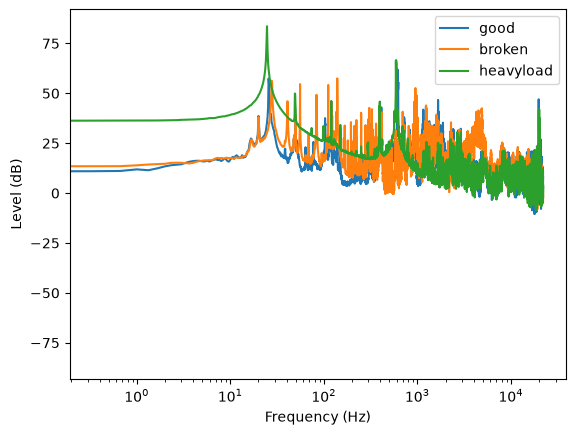

In [7]:
# plots average spectrum per class. on training
freqs = np.fft.rfftfreq(132300, 1 / 44100)

for label in range(3):
    clips = X_train[y_train == label]
    spectrum = np.mean([np.abs(np.fft.rfft(x)) for x in clips], axis=0)
    plt.plot(freqs, 20 * np.log10(spectrum + 1e-9), label=CLASS_NAMES[label])

plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Level (dB)")
plt.legend()
plt.show()

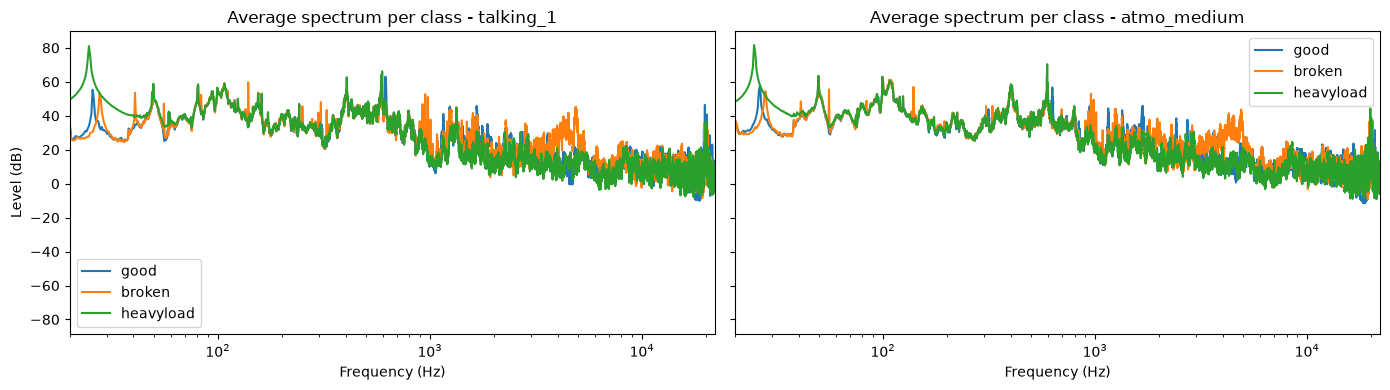

In [8]:
# average spectrum per class on validation
val_recordings = np.array(val_recordings)
freqs = np.fft.rfftfreq(132300, 1 / 44100)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for i, rec in enumerate(["talking_1", "atmo_medium"]):
    for label in range(3):
        clips = X_val[(y_val == label) & (val_recordings == rec)]
        spectrum = np.mean([np.abs(np.fft.rfft(x)) for x in clips], axis=0)
        axes[i].plot(freqs, 20 * np.log10(spectrum + 1e-9), label=CLASS_NAMES[label])

    axes[i].set_xscale("log")
    axes[i].set_xlim(20, 22050)
    axes[i].set_title("Average spectrum per class - " + rec)
    axes[i].set_xlabel("Frequency (Hz)")
    axes[i].legend()

axes[0].set_ylabel("Level (dB)")
plt.tight_layout()
plt.show()

## 3. Cleaning checks: DC offset and duplicates

In [9]:
# checks for dc offset and duplicates 
print("Mean of first 5 clips:", [round(float(np.mean(x)), 6) for x in X_train[:5]])   # should be 0
print("Unique train clips:", len(set(x.tobytes() for x in X_train)), "of", len(X_train)) # should be all

Mean of first 5 clips: [-0.0, 0.0, -0.0, 0.0, 0.0]
Unique train clips: 357 of 357


## 4. Loudness, clipping and class balance

In [10]:
# does rms to find average loudness per class
# clipping to find if some clips are too lound and goes over max.
# counts is to find imbalance between classes, should be close to 1

for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val)]:
    rms = np.array([np.sqrt(np.mean(x ** 2)) for x in X])
    clipped = np.array([np.max(np.abs(x)) >= 0.99 for x in X])
    counts = np.bincount(y)

    print(name)
    print("  mean loudness (RMS) per class:", [round(float(rms[y == c].mean()), 4) for c in range(3)])
    print("  clipped clips:", clipped.sum())
    print("  clips per class:", counts, "| largest/smallest =", round(counts.max() / counts.min(), 2))

train
  mean loudness (RMS) per class: [0.0871, 0.0566, 0.2599]
  clipped clips: 1
  clips per class: [105 124 128] | largest/smallest = 1.22
val
  mean loudness (RMS) per class: [0.1254, 0.1126, 0.2367]
  clipped clips: 16
  clips per class: [140 146 156] | largest/smallest = 1.11


## 5. Peak, peak-to-peak and RMS per class

In [11]:
# Peak value
peak_train = np.max(np.abs(X_train), axis=1)
peak_val = np.max(np.abs(X_val), axis=1)

for c in range(3):
    print(CLASS_NAMES[c], "mean peak:", round(float(peak_train[y_train == c].mean()), 4))

good mean peak: 0.2759
broken mean peak: 0.2571
heavyload mean peak: 0.5824


In [12]:
# Peak to Peak value
p2p_train = np.max(X_train, axis=1) - np.min(X_train, axis=1)
p2p_val = np.max(X_val, axis=1) - np.min(X_val, axis=1)

for c in range(3):
    print(CLASS_NAMES[c], "mean peak-to-peak:", round(float(p2p_train[y_train == c].mean()), 4))

good mean peak-to-peak: 0.5244
broken mean peak-to-peak: 0.4973
heavyload mean peak-to-peak: 1.1544


In [13]:
# rms, average loudness
rms_train = np.sqrt(np.mean(X_train ** 2, axis=1))
rms_val = np.sqrt(np.mean(X_val ** 2, axis=1))

for c in range(3):
    print(CLASS_NAMES[c], "mean RMS:", round(float(rms_train[y_train == c].mean()), 4))

good mean RMS: 0.0871
broken mean RMS: 0.0566
heavyload mean RMS: 0.2599


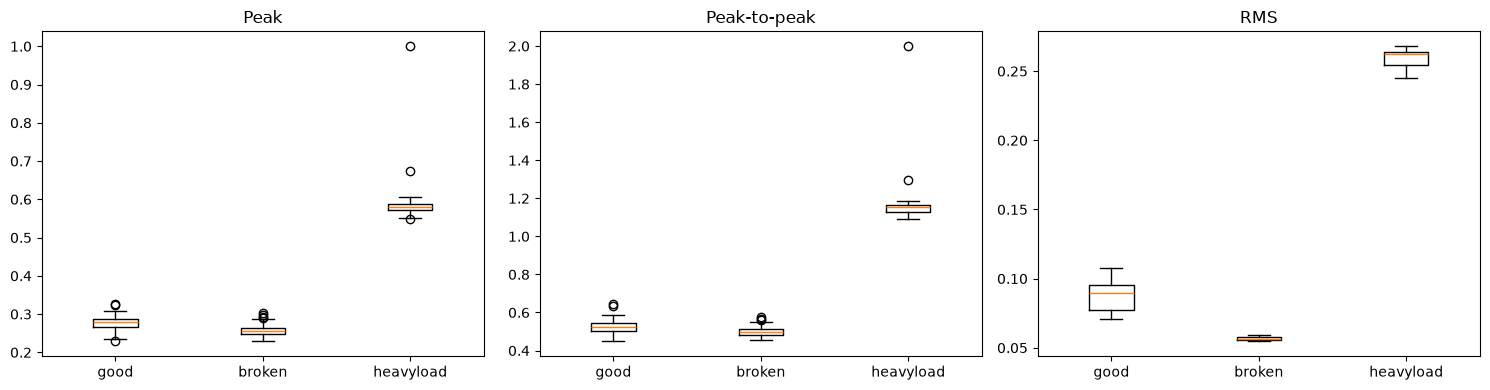

In [14]:
# plot per class

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (title, values) in enumerate([("Peak", peak_train), ("Peak-to-peak", p2p_train), ("RMS", rms_train)]):
    axes[i].boxplot([values[y_train == c] for c in range(3)])
    axes[i].set_xticklabels(CLASS_NAMES)
    axes[i].set_title(title)

plt.tight_layout()
plt.show()